# Analysis and figures

Evaluation of the experiment results used in the thesis. This is the original analysis notebook, with its outputs from the final run. The same metrics are available as reusable functions in [`rag_flint.evaluation`](../src/rag_flint/evaluation) and can be recomputed with `python scripts/evaluate.py`.

The raw result files (`embed_<embedder>__gen_<generator>.json`) are expected in `results/raw/`.

## Setup

In [ ]:
!pip install langdetect

## 1. Schema adherence and language of the generated frames
A frame adheres to the schema when it contains all five FLINT keys. The language of each frame is detected with `langdetect` (the prompt and the law are Dutch).

--- Starting Analysis ---
Processing: embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json...


--- Aggregated Analysis Complete 

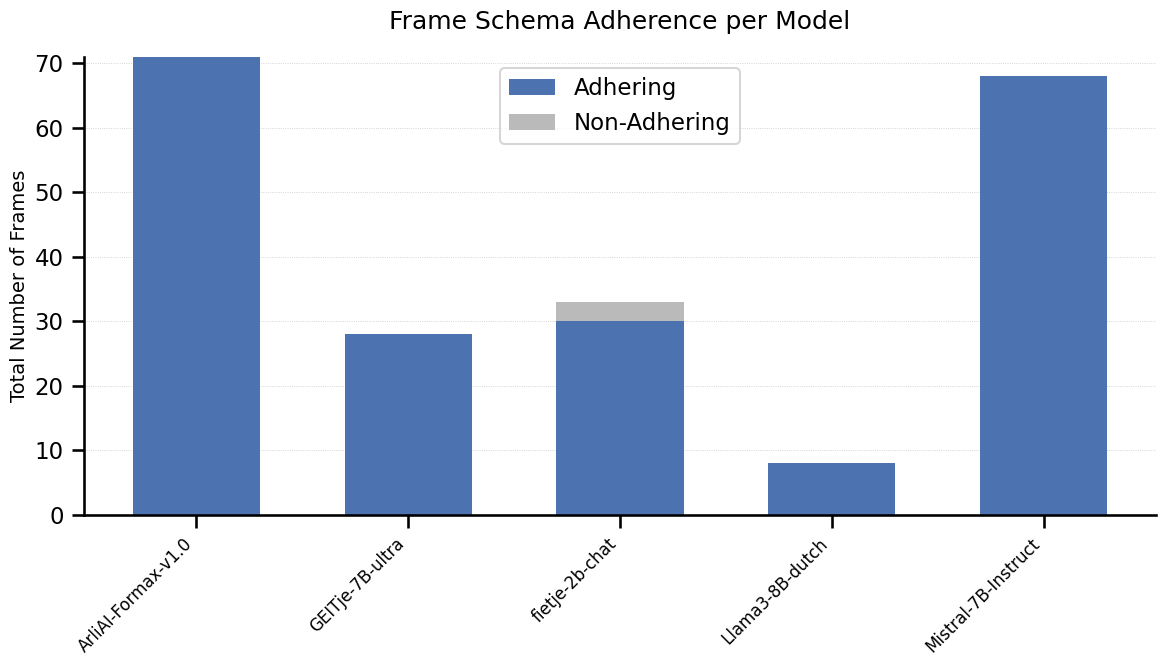

Plot 2 saved successfully as 'language_distribution.pdf'


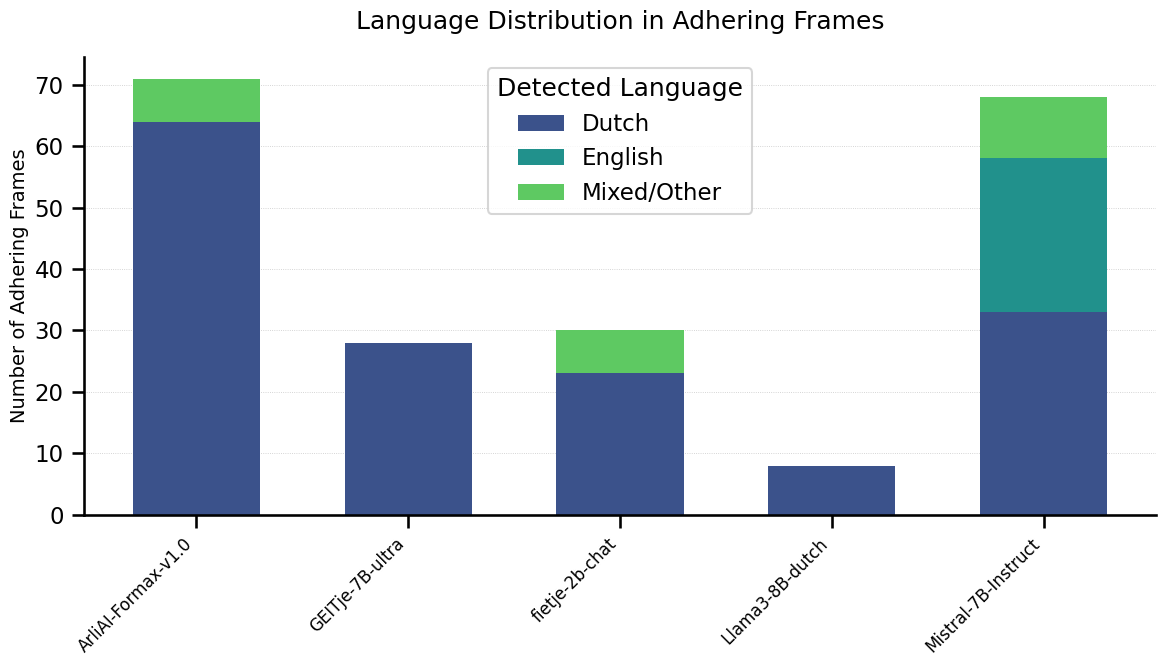

In [ ]:
import json
import os
from collections import defaultdict
from langdetect import detect, DetectorFactory
from langdetect.lang_detect_exception import LangDetectException
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Seed the language detector for reproducible results
DetectorFactory.seed = 0

def analyze_frames(data):
    """
    Analyzes the frames within the JSON data for schema adherence and language usage.

    Args:
        data (list): A list of test case dictionaries loaded from the JSON file.

    Returns:
        tuple: A tuple containing two dictionaries:
               - schema_counts: Counts of adhering vs. non-adhering frames.
               - lang_counts: Counts of Dutch, English, and mixed-language frames.
    """
    schema_counts = defaultdict(int)
    lang_counts = defaultdict(int)
    required_keys = {'actor', 'action', 'object', 'conditions', 'results'}
    lang_map = {'nl': 'dutch', 'en': 'english'}

    for test_case in data:
        if 'final_unique_frames' not in test_case or not isinstance(test_case['final_unique_frames'], list):
            continue
        for frame in test_case['final_unique_frames']:
            if isinstance(frame, dict) and required_keys.issubset(frame.keys()):
                schema_counts['adhering'] += 1
                frame_text = " ".join(str(v) for v in frame.values() if isinstance(v, str))
                if not frame_text.strip():
                    lang_counts['unknown'] += 1
                    continue
                try:
                    lang = detect(frame_text)
                    lang_category = lang_map.get(lang, 'mixed/other')
                    lang_counts[lang_category] += 1
                except LangDetectException:
                    lang_counts['unknown'] += 1
            else:
                schema_counts['non_adhering'] += 1
    return dict(schema_counts), dict(lang_counts)

def plot_summary_results(aggregated_results):
    """
    Generates, displays, and saves two separate, academically styled bar charts.

    Args:
        aggregated_results (dict): Aggregated analysis results for each generative model.
    """
    if not aggregated_results:
        print("No results to plot.")
        return

    # --- Set plotting style ---
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("talk")

    name_map = {
        'ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0': 'ArliAI-Formax-v1.0',
        'BramVanroy_GEITje-7B-ultra': 'GEITje-7B-ultra',
        'BramVanroy_fietje-2b-chat': 'fietje-2b-chat',
        'ReBatch_Llama-3-8B-dutch': 'Llama3-8B-dutch',
        'mistralai_Mistral-7B-Instruct-v0.1': 'Mistral-7B-Instruct'
    }

    model_names = list(aggregated_results.keys())
    short_model_names = [name_map.get(name, name) for name in model_names]

    # --- Data Preparation ---
    schema_adhering = np.array([res['schema'].get('adhering', 0) for res in aggregated_results.values()])
    schema_non_adhering = np.array([res['schema'].get('non_adhering', 0) for res in aggregated_results.values()])
    lang_dutch = np.array([res['lang'].get('dutch', 0) for res in aggregated_results.values()])
    lang_english = np.array([res['lang'].get('english', 0) for res in aggregated_results.values()])
    lang_mixed = np.array([res['lang'].get('mixed/other', 0) for res in aggregated_results.values()])
    x = np.arange(len(model_names))
    width = 0.6

    # ===================================================================
    #                           PLOT 1: SCHEMA ADHERENCE
    # ===================================================================
    fig1, ax1 = plt.subplots(figsize=(12, 7))

    ax1.set_title('Frame Schema Adherence per Model', fontsize=18, pad=20)

    ax1.bar(x, schema_adhering, width, label='Adhering', color='#4c72b0')
    ax1.bar(x, schema_non_adhering, width, bottom=schema_adhering, label='Non-Adhering', color='#bababa')

    ax1.set_ylabel('Total Number of Frames', fontsize=14)
    ax1.legend()
    sns.despine(ax=ax1)

    ax1.yaxis.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
    ax1.set_axisbelow(True)

    ax1.set_xticks(x)
    ax1.set_xticklabels(short_model_names, rotation=45, ha="right", fontsize=12)

    fig1.tight_layout()
    output_filename1 = 'schema_adherence.pdf'
    fig1.savefig(output_filename1, bbox_inches='tight')
    print(f"Plot 1 saved successfully as '{output_filename1}'")
    plt.show()

    # ===================================================================
    #                     PLOT 2: LANGUAGE DISTRIBUTION
    # ===================================================================
    fig2, ax2 = plt.subplots(figsize=(12, 7))

    ax2.set_title('Language Distribution in Adhering Frames', fontsize=18, pad=20)
    language_palette = sns.color_palette("viridis", 3)

    ax2.bar(x, lang_dutch, width, label='Dutch', color=language_palette[0])
    ax2.bar(x, lang_english, width, bottom=lang_dutch, label='English', color=language_palette[1])
    ax2.bar(x, lang_mixed, width, bottom=lang_dutch + lang_english, label='Mixed/Other', color=language_palette[2])

    ax2.set_ylabel('Number of Adhering Frames', fontsize=14)
    ax2.legend(title='Detected Language')
    sns.despine(ax=ax2)

    ax2.yaxis.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
    ax2.set_axisbelow(True)

    ax2.set_xticks(x)
    ax2.set_xticklabels(short_model_names, rotation=45, ha="right", fontsize=12)

    fig2.tight_layout()
    output_filename2 = 'language_distribution.pdf'
    fig2.savefig(output_filename2, bbox_inches='tight')
    print(f"Plot 2 saved successfully as '{output_filename2}'")
    plt.show()

# --- Main Analysis Logic ---

json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

aggregated_results = defaultdict(lambda: {'schema': defaultdict(int), 'lang': defaultdict(int)})

print("--- Starting Analysis ---")
for filepath in json_files:
    if not os.path.exists(filepath):
        print(f"Warning: File not found at '{filepath}'. Skipping.")
        continue

    print(f"Processing: {os.path.basename(filepath)}...")
    try:
        model_name = filepath.split('__gen_')[1].replace('.json', '')
        with open(filepath, 'r', encoding='utf-8') as f:
            data = json.load(f)
    except Exception as e:
        print(f"  - Error loading or parsing file: {e}")
        continue

    schema_counts, lang_counts = analyze_frames(data)

    for key, value in schema_counts.items():
        aggregated_results[model_name]['schema'][key] += value
    for key, value in lang_counts.items():
        aggregated_results[model_name]['lang'][key] += value

print("\n\n--- Aggregated Analysis Complete ---")

if aggregated_results:
    plot_summary_results(aggregated_results)
else:
    print("\nNo data was successfully processed. No plot will be generated.")


## 2. Retrieval quality: Recall@k against a hand-annotated ground truth
For each test case, the relevant chunks were annotated by hand (see `data/ground_truth.json`).

In [ ]:
import pandas as pd
from typing import List, Dict

def calculate_recall_at_k(retrieved_ids: List[str], relevant_ids: List[str], k: int) -> float:
    """
    Calculates Recall@k.

    Recall is defined as the number of relevant items retrieved out of the
    total number of relevant items. Recall@k considers only the top k
    retrieved items.

    Args:
        retrieved_ids (List[str]): The ordered list of chunk IDs retrieved by the model.
        relevant_ids (List[str]): The list of ground truth (relevant) chunk IDs.
        k (int): The cutoff for the retrieval list (e.g., 3, 5, 10).

    Returns:
        float: The recall score @k, from 0.0 to 1.0.
    """
    # Take the top k retrieved IDs
    top_k_retrieved = retrieved_ids[:k]

    # Convert lists to sets for efficient intersection
    retrieved_set = set(top_k_retrieved)
    relevant_set = set(relevant_ids)

    # Find the number of relevant items that were retrieved (true positives)
    true_positives = len(retrieved_set.intersection(relevant_set))

    # Total number of actual relevant items
    total_relevant = len(relevant_set)

    if total_relevant == 0:
        return 0.0 # Avoid division by zero

    # Calculate recall
    recall = true_positives / total_relevant
    return recall

def perform_recall_analysis(retrieved_data: Dict, ground_truth_data: Dict):
    """
    Performs the full recall analysis and prints a summary table.

    Args:
        retrieved_data (Dict): A nested dictionary with the retrieved chunk IDs for each embedder.
        ground_truth_data (Dict): A dictionary with the ground truth chunk IDs for each test case.
    """
    analysis_results = []

    # Iterate through each embedder and their results
    for embedder_name, test_cases in retrieved_data.items():
        print(f"Analyzing Embedder: {embedder_name}...")
        for tc_id, retrieved_ids in test_cases.items():
            if tc_id not in ground_truth_data:
                print(f"  - Warning: Ground truth for {tc_id} not found. Skipping.")
                continue

            relevant_ids = ground_truth_data[tc_id]

            # Calculate recall at different values of k
            recall_at_3 = calculate_recall_at_k(retrieved_ids, relevant_ids, 3)
            recall_at_5 = calculate_recall_at_k(retrieved_ids, relevant_ids, 5)
            recall_at_10 = calculate_recall_at_k(retrieved_ids, relevant_ids, 10)

            analysis_results.append({
                "Embedder": embedder_name,
                "Test Case": tc_id,
                "Recall@3": recall_at_3,
                "Recall@5": recall_at_5,
                "Recall@10": recall_at_10
            })

    # Use pandas to create a clean, readable table
    df = pd.DataFrame(analysis_results)

    print("\n--- Recall Analysis Results per Test Case ---")
    print(df.to_string(index=False))

    # Calculate and display the average recall for each embedder
    avg_df = df.groupby("Embedder")[["Recall@3", "Recall@5", "Recall@10"]].mean().reset_index()

    print("\n\n--- Average Recall Across All Test Cases ---")
    print(avg_df.to_string(index=False))


if __name__ == '__main__':
    # 1. Your Retrieved Results Data
    # (Pasted directly from your previous output)
    retrieved_results = {
        'Gerwin/legal-bert-dutch-english': {
            'TC01': ['chunk_183', 'chunk_020', 'chunk_137', 'chunk_174', 'chunk_163', 'chunk_135', 'chunk_119', 'chunk_078', 'chunk_096', 'chunk_148'],
            'TC02': ['chunk_142', 'chunk_044', 'chunk_197', 'chunk_048', 'chunk_137', 'chunk_051', 'chunk_049', 'chunk_052', 'chunk_141', 'chunk_037'],
            'TC03': ['chunk_142', 'chunk_137', 'chunk_058', 'chunk_197', 'chunk_073', 'chunk_072', 'chunk_020', 'chunk_173', 'chunk_074', 'chunk_003'],
            'TC04': ['chunk_037', 'chunk_158', 'chunk_197', 'chunk_148', 'chunk_128', 'chunk_132', 'chunk_174', 'chunk_204', 'chunk_137', 'chunk_141']
        },
        'pdelobelle/robbert-v2-dutch-base': {
            'TC01': ['chunk_020', 'chunk_173', 'chunk_003', 'chunk_163', 'chunk_119', 'chunk_036', 'chunk_148', 'chunk_100', 'chunk_100', 'chunk_074'],
            'TC02': ['chunk_142', 'chunk_049', 'chunk_052', 'chunk_044', 'chunk_048', 'chunk_051', 'chunk_003', 'chunk_020', 'chunk_141', 'chunk_037'],
            'TC03': ['chunk_142', 'chunk_062', 'chunk_061', 'chunk_060', 'chunk_148', 'chunk_072', 'chunk_073', 'chunk_020', 'chunk_098', 'chunk_074'],
            'TC04': ['chunk_037', 'chunk_158', 'chunk_197', 'chunk_128', 'chunk_148', 'chunk_204', 'chunk_132', 'chunk_174', 'chunk_135', 'chunk_178']
        }
    }

    # 2. Your Ground Truth Data
    # (Pasted directly from your prompt)
    ground_truth = {
        'TC01': ['chunk_034', 'chunk_035', 'chunk_112', 'chunk_119', 'chunk_120', 'chunk_122', 'chunk_095', 'chunk_077', 'chunk_115', 'chunk_116'],
        'TC02': ['chunk_011', 'chunk_012', 'chunk_013', 'chunk_014', 'chunk_015', 'chunk_048', 'chunk_049', 'chunk_069', 'chunk_070', 'chunk_131'],
        'TC03': ['chunk_016', 'chunk_017', 'chunk_018', 'chunk_058', 'chunk_059', 'chunk_062', 'chunk_074', 'chunk_071', 'chunk_130', 'chunk_131'],
        'TC04': ['chunk_010', 'chunk_037', 'chunk_126', 'chunk_155', 'chunk_156', 'chunk_157', 'chunk_158', 'chunk_160', 'chunk_148', 'chunk_124']
    }

    # 3. Perform the analysis
    perform_recall_analysis(retrieved_results, ground_truth)



Analyzing Embedder: Gerwin/legal-bert-dutch-english...
Analyzing Embedder: pdelobelle/robbert-v2-dutch-base...

--- Recall Analysis Results per Test Case ---
                        Embedder Test Case  Recall@3  Recall@5  Recall@10
 Gerwin/legal-bert-dutch-english      TC01       0.0       0.0        0.1
 Gerwin/legal-bert-dutch-english      TC02       0.0       0.1        0.2
 Gerwin/legal-bert-dutch-english      TC03       0.1       0.1        0.2
 Gerwin/legal-bert-dutch-english      TC04       0.2       0.3        0.3
pdelobelle/robbert-v2-dutch-base      TC01       0.0       0.1        0.1
pdelobelle/robbert-v2-dutch-base      TC02       0.1       0.2        0.2
pdelobelle/robbert-v2-dutch-base      TC03       0.1       0.1        0.2
pdelobelle/robbert-v2-dutch-base      TC04       0.2       0.3        0.3


--- Average Recall Across All Test Cases ---
                        Embedder  Recall@3  Recall@5  Recall@10
 Gerwin/legal-bert-dutch-english     0.075     0.125        0.2
p

## 3. Factual grounding: word overlap between frames and the retrieved law text

--- Starting Jaccard Similarity Analysis ---
Processing: embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json...
Processing: embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json...
Processing: embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json...

--- Analysis Co

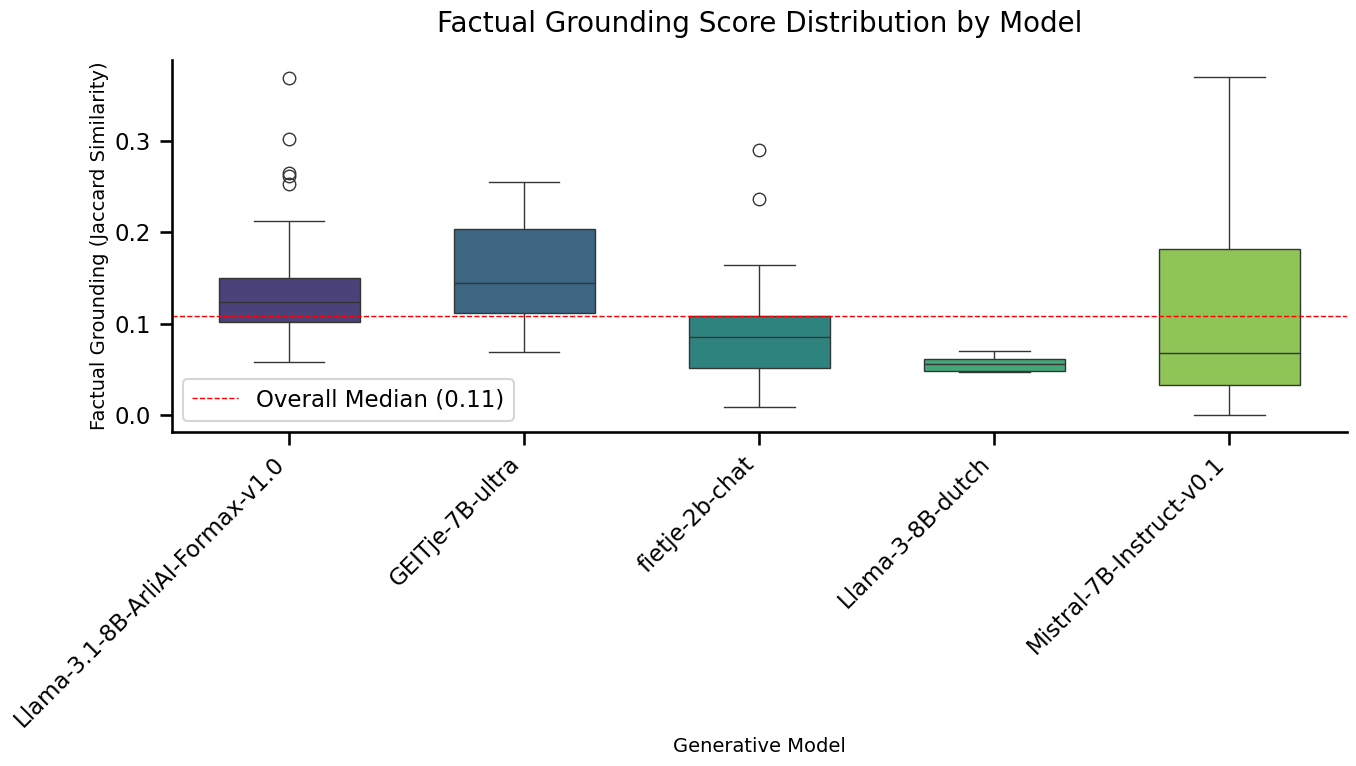

In [ ]:
import json
import os
import re
from collections import defaultdict
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

def calculate_jaccard_similarity(frame: dict) -> float:
    """
    Calculates the Jaccard similarity between a frame's content and its retrieved chunks.
    This serves as a measure of factual grounding.

    Args:
        frame (dict): A dictionary representing a single generated frame,
                      which must contain a 'retrieved_chunks' key.

    Returns:
        float: The Jaccard similarity score, from 0.0 to 1.0.
    """
    # Combine all text fields from the frame for analysis
    frame_text = " ".join(str(frame.get(key, '')) for key in ['actor', 'action', 'object', 'conditions', 'results'])

    if not frame.get('retrieved_chunks'):
        return 0.0

    # Extract unique, lowercased words from the frame's content
    frame_terms = set(re.findall(r'\b\w+\b', frame_text.lower()))

    # Extract unique, lowercased words from all retrieved chunks
    chunk_terms = set()
    for chunk in frame['retrieved_chunks']:
        # === THIS IS THE CORRECTED LINE ===
        # Your data structure uses the key 'text', not 'page_content'.
        chunk_text = chunk.get('text', '').lower()
        # ==================================
        chunk_terms.update(re.findall(r'\b\w+\b', chunk_text))

    if not frame_terms or not chunk_terms:
        return 0.0

    # Calculate Jaccard similarity
    intersection = len(frame_terms.intersection(chunk_terms))
    union = len(frame_terms.union(chunk_terms))

    return intersection / union if union > 0 else 0.0

def plot_grounding_scores_by_model(model_scores: dict):
    """
    Generates an academic-style box plot of Jaccard similarity scores for each model.

    Args:
        model_scores (dict): A dictionary mapping model names to lists of their scores.
    """
    # --- Set a professional, academic plotting style ---
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("talk")

    # Prepare data for Seaborn boxplot
    models = []
    scores = []
    for model_name, score_list in model_scores.items():
        # Shorten model names for better readability on the plot
        short_name = model_name.split('/')[-1].replace('ArliAI_', '').replace('_', '-')
        models.extend([short_name] * len(score_list))
        scores.extend(score_list)

    # --- Create the Plot ---
    fig, ax = plt.subplots(figsize=(14, 8))

    # New line that fixes the warning
    sns.boxplot(x=models, y=scores, hue=models, ax=ax, palette="viridis", width=0.6, legend=False)

    ax.set_title('Factual Grounding Score Distribution by Model', fontsize=20, pad=20)
    ax.set_ylabel('Factual Grounding (Jaccard Similarity)', fontsize=14)
    ax.set_xlabel('Generative Model', fontsize=14)

    # Rotate x-axis labels for readability
    plt.xticks(rotation=45, ha='right')

    # Add a horizontal line at the median of all scores for reference
    median_all = np.median(scores)
    ax.axhline(median_all, ls='--', color='red', lw=1, label=f'Overall Median ({median_all:.2f})')

    ax.legend()
    sns.despine(ax=ax) # Clean up the plot border
    fig.tight_layout()

    # --- Save the Figure ---
    output_filename = 'jaccard_similarity_by_model.pdf'
    fig.savefig(output_filename, bbox_inches='tight')
    print(f"Plot saved successfully as '{output_filename}'")

    plt.show()


# ===================================================================
#                           MAIN EXECUTION
# ===================================================================

# In a notebook, list the paths to your JSON result files

json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

# This dictionary will store the scores for each model
# e.g., {'ModelA': [0.5, 0.6, ...], 'ModelB': [0.4, 0.7, ...]}
grounding_scores_by_model = defaultdict(list)

print("--- Starting Jaccard Similarity Analysis ---")

# Check if json_files list is populated
if not json_files:
    print("Warning: The 'json_files' list is empty. Please add paths to your result files.")
else:
    for filepath in json_files:
        if not os.path.exists(filepath):
            print(f"Warning: File not found at '{filepath}'. Skipping.")
            continue

        print(f"Processing: {os.path.basename(filepath)}...")
        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                # Assuming the JSON file contains a list of result dictionaries
                results_data = json.load(f)

            for result in results_data:
                model_name = result.get('generative_model', 'Unknown_Model')

                for frame in result.get('final_unique_frames', []):
                    # Add retrieved_chunks to the frame dict for the function
                    frame['retrieved_chunks'] = result.get('retrieved_chunks', [])
                    score = calculate_jaccard_similarity(frame)
                    grounding_scores_by_model[model_name].append(score)

        except Exception as e:
            print(f"  - Error loading or parsing file: {e}")
            continue

    print("\n--- Analysis Complete ---")

    # Check if any scores were calculated before plotting
    if grounding_scores_by_model:
        plot_grounding_scores_by_model(grounding_scores_by_model)
    else:
        print("No data was successfully processed. No plot will be generated.")

## 4. How different are the chunks the two embedders retrieve?

--- Aggregating Retrieved Articles by Embedder ---

--- Jaccard Scores Calculated ---
TC01    0.266667
TC02    0.666667
TC03    0.333333
TC04    0.666667
dtype: float64

Plot saved successfully as 'embedder_jaccard_overlap.pdf'


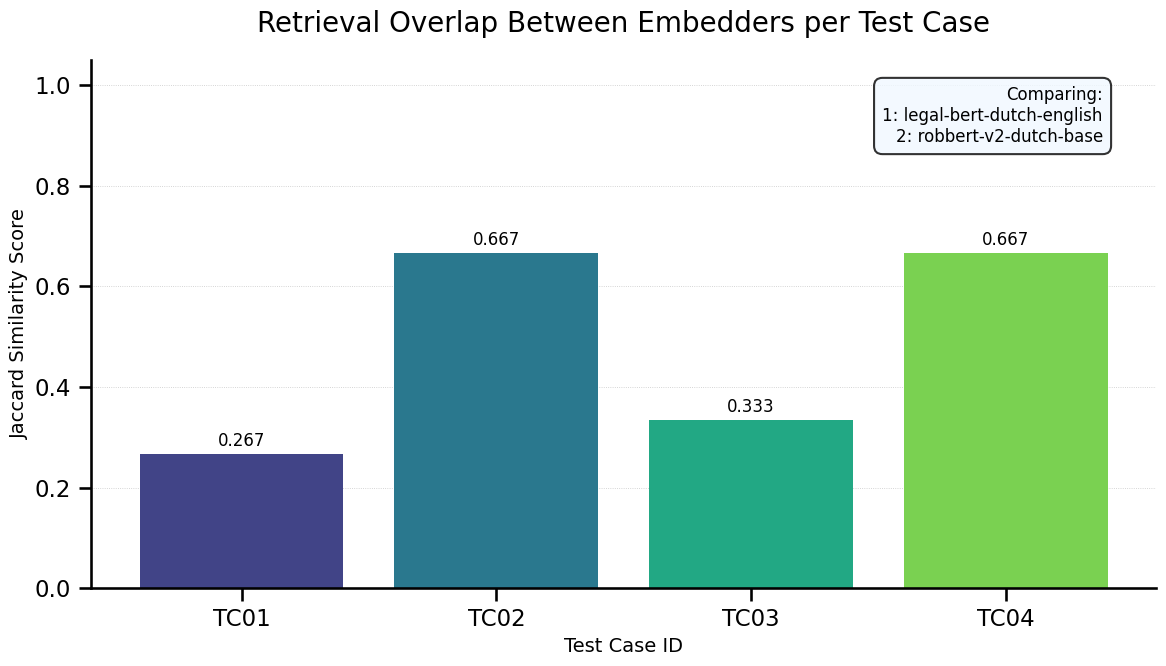

In [ ]:
import json
import os
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def analyze_embedder_overlap(json_files: list, embedder1_key: str, embedder2_key: str):
    """
    Analyzes and plots the Jaccard similarity of retrieved articles
    between two specified embedders for each test case.

    Args:
        json_files (list): A list of paths to the result JSON files.
        embedder1_key (str): A unique substring identifying the first embedder in filenames.
        embedder2_key (str): A unique substring identifying the second embedder in filenames.
    """
    # This nested dictionary will store the sets of retrieved articles.
    # Structure: {test_case_id: {embedder_name: {set_of_article_texts}}}
    retrieved_data = defaultdict(lambda: defaultdict(set))

    # Store embedder full names for the legend
    embedder_names = {}

    print("--- Aggregating Retrieved Articles by Embedder ---")
    for filepath in json_files:
        if not os.path.exists(filepath):
            print(f"Warning: File not found at '{filepath}'. Skipping.")
            continue

        filename = os.path.basename(filepath)
        current_embedder_name = ""

        try:
            with open(filepath, 'r', encoding='utf-8') as f:
                results_data = json.load(f)

            # Process only if the file contains data
            if not results_data:
                continue

            # Identify embedder from the first result object in the file
            full_embedder_name = results_data[0].get('embedding_model', '')
            if embedder1_key in full_embedder_name:
                current_embedder_name = "Embedder 1"
                embedder_names["Embedder 1"] = full_embedder_name.split('/')[-1]
            elif embedder2_key in full_embedder_name:
                current_embedder_name = "Embedder 2"
                embedder_names["Embedder 2"] = full_embedder_name.split('/')[-1]
            else:
                continue

            for result in results_data:
                test_case_id = result.get('test_case_id', 'Unknown_TC')
                for chunk in result.get('retrieved_chunks', []):
                    # Use the chunk's text as its unique identifier
                    chunk_text = chunk.get('text', '')
                    if chunk_text:
                        retrieved_data[test_case_id][current_embedder_name].add(chunk_text)

        except Exception as e:
            print(f"  - Error processing file {filename}: {e}")
            continue

    # --- Calculate Jaccard Similarity for each test case ---
    jaccard_scores = {}
    for test_case_id, embedders in retrieved_data.items():
        if "Embedder 1" in embedders and "Embedder 2" in embedders:
            set1 = embedders["Embedder 1"]
            set2 = embedders["Embedder 2"]

            intersection = len(set1.intersection(set2))
            union = len(set1.union(set2))

            score = intersection / union if union > 0 else 0
            jaccard_scores[test_case_id] = score

    if not jaccard_scores:
        print("\nCould not calculate scores. Ensure files for both embedders were found and are not empty.")
        return

    print("\n--- Jaccard Scores Calculated ---")
    print(pd.Series(jaccard_scores).sort_index())

    # --- Plotting the Results ---
    plot_data = pd.DataFrame(list(jaccard_scores.items()), columns=['Test Case', 'Jaccard Similarity']).sort_values('Test Case')

    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("talk")

    fig, ax = plt.subplots(figsize=(12, 7))

    palette = sns.color_palette("viridis", len(plot_data))

    bars = ax.bar(plot_data['Test Case'], plot_data['Jaccard Similarity'], color=palette)

    ax.set_title('Retrieval Overlap Between Embedders per Test Case', fontsize=20, pad=20)
    ax.set_ylabel('Jaccard Similarity Score', fontsize=14)
    ax.set_xlabel('Test Case ID', fontsize=14)

    ax.set_ylim(0, 1.05)  # Jaccard score is between 0 and 1

    # Subtle dotted horizontal gridlines
    ax.yaxis.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    ax.bar_label(bars, fmt='%.3f', fontsize=12, padding=3)

    # Add a legend explaining the embedders
    legend_text = f"Comparing:\n1: {embedder_names.get('Embedder 1', embedder1_key)}\n2: {embedder_names.get('Embedder 2', embedder2_key)}"
    ax.text(0.95, 0.95, legend_text, transform=ax.transAxes, fontsize=12,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round,pad=0.5', fc='aliceblue', alpha=0.8))

    sns.despine(ax=ax)
    fig.tight_layout()

    output_filename = 'embedder_jaccard_overlap.pdf'
    fig.savefig(output_filename, bbox_inches='tight')
    print(f"\nPlot saved successfully as '{output_filename}'")

    plt.show()

# ===================================================================
#                           MAIN EXECUTION
# ===================================================================

# Define unique parts of the model names to identify each embedder
EMBEDDER_1_KEY = 'legal-bert'
EMBEDDER_2_KEY = 'robbert-v2'

# Provide the list of all JSON result files
json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

if not json_files:
    print("Warning: The 'json_files' list is empty. Please add paths to your result files.")
else:
    analyze_embedder_overlap(json_files, EMBEDDER_1_KEY, EMBEDDER_2_KEY)


## 5. Mean top-1 retrieval score per embedder


--- Calculated Retrieval Summary ---
             embedder_short      mean       std
0  legal-bert-dutch-english  0.654269  0.021495
1     robbert-v2-dutch-base  0.717200  0.021326

Plot saved successfully as 'retrieval_score_comparison.pdf'


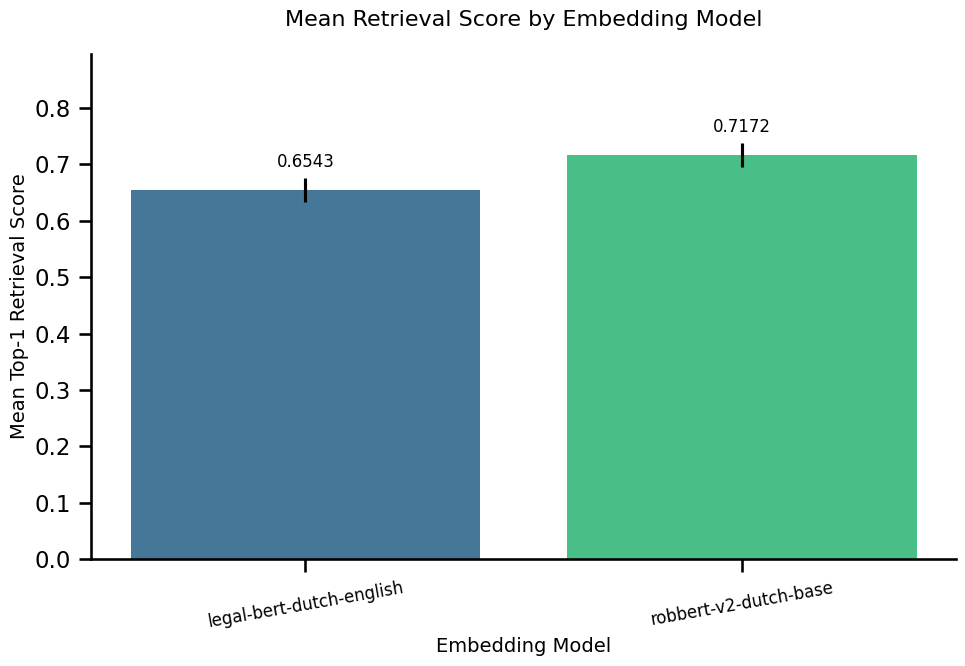

In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_process_data(json_files):
    """
    Loads data from a list of JSON files and processes it into a pandas DataFrame.
    Extracts only the data needed for the retrieval score comparison.
    """
    all_results = []
    for file_path in json_files:
        if not os.path.exists(file_path):
            print(f"Warning: File not found, skipping: {file_path}")
            continue

        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                for test_case in data:
                    retrieved_chunks = test_case.get('retrieved_chunks', [])
                    top_1_score = retrieved_chunks[0].get('retrieval_score', 0) if retrieved_chunks else 0

                    all_results.append({
                        'embedder': test_case.get('embedding_model'),
                        'top_1_score': top_1_score,
                    })
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON from {file_path}.")
                continue

    return pd.DataFrame(all_results)

def plot_retrieval_score_comparison(df):
    """
    Creates a bar chart comparing the mean Top-1 retrieval scores of the embedders,
    with corrected code and unified academic styling.
    """
    retrieval_summary = df.groupby('embedder')['top_1_score'].agg(['mean', 'std']).reset_index()
    retrieval_summary['embedder_short'] = retrieval_summary['embedder'].apply(lambda x: x.split('/')[-1])

    print("\n--- Calculated Retrieval Summary ---")
    print(retrieval_summary[['embedder_short', 'mean', 'std']])

    # Create the plot using the object-oriented API
    fig, ax = plt.subplots(figsize=(10, 7))
    colors = sns.color_palette("viridis", n_colors=len(retrieval_summary))

    bars = ax.bar(
        retrieval_summary['embedder_short'],
        retrieval_summary['mean'],
        yerr=retrieval_summary['std'],
        capsize=5,
        color=colors,
        alpha=0.9
    )

    ax.set_ylabel('Mean Top-1 Retrieval Score', fontsize=14)
    ax.set_xlabel('Embedding Model', fontsize=14)
    ax.set_title('Mean Retrieval Score by Embedding Model', fontsize=16, pad=20)
    ax.tick_params(axis='x', rotation=10, labelsize=12)

    if not retrieval_summary.empty:
        ax.set_ylim(0, retrieval_summary['mean'].max() * 1.25)

    ax.bar_label(bars, fmt='%.4f', fontsize=12, padding=5)

    sns.despine(ax=ax)
    fig.tight_layout()

    output_filename = 'retrieval_score_comparison.pdf'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved successfully as '{output_filename}'")

    plt.show()

# ===================================================================
#                           MAIN EXECUTION
# ===================================================================

# This list should contain the paths to all your JSON result files.
json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

# --- Set a professional plotting style ---
# This ensures a clean, academic look and feel.
plt.style.use('seaborn-v0_8-paper')
# This crucial line scales up fonts and line weights for better legibility.
sns.set_context("talk")

# Load data
results_df = load_and_process_data(json_files)

# Generate the plot
if not results_df.empty:
    plot_retrieval_score_comparison(results_df)
else:
    print("Could not generate the plot because no data was loaded.")

## 6. Number of unique frames per model and embedder


--- Aggregated Frame Generation Summary ---
             embedder_short      generator_short  num_frames
0  legal-bert-dutch-english   ArliAI-Formax-v1.0          37
1  legal-bert-dutch-english      GEITje-7B-ultra          16
2  legal-bert-dutch-english       fietje-2b-chat          20
3  legal-bert-dutch-english     Llama-3-8B-dutch           4
4  legal-bert-dutch-english  Mistral-7B-Instruct          35
5     robbert-v2-dutch-base   ArliAI-Formax-v1.0          34
6     robbert-v2-dutch-base      GEITje-7B-ultra          12
7     robbert-v2-dutch-base       fietje-2b-chat          13
8     robbert-v2-dutch-base     Llama-3-8B-dutch           4
9     robbert-v2-dutch-base  Mistral-7B-Instruct          33

Plot saved successfully as 'frame_generation_comparison.pdf'


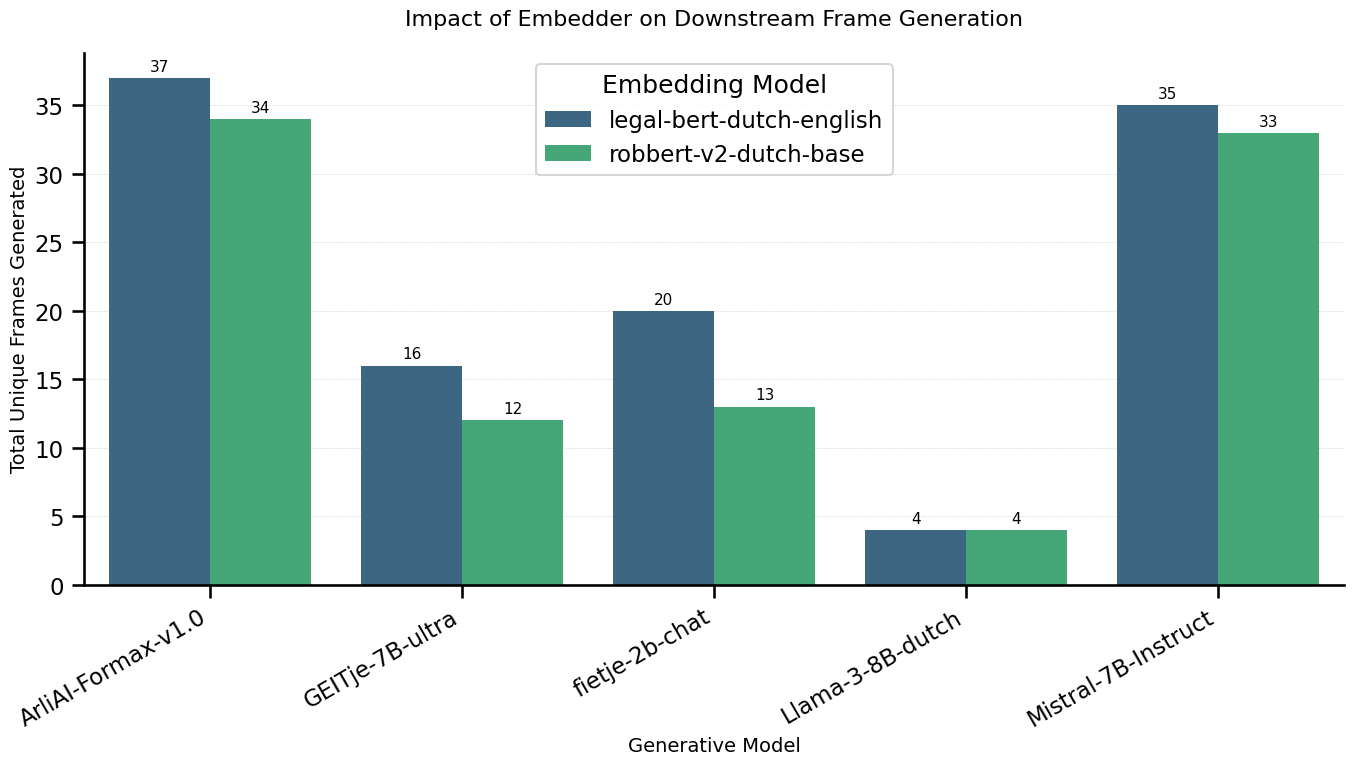

In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_process_data(json_files):
    """
    Loads data from a list of JSON files and processes it into a pandas DataFrame,
    extracting only the data needed for the frame generation plot.
    """
    all_results = []
    for file_path in json_files:
        if not os.path.exists(file_path):
            print(f"Warning: File not found, skipping: {file_path}")
            continue

        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                for test_case in data:
                    all_results.append({
                        'embedder': test_case.get('embedding_model'),
                        'generator': test_case.get('generative_model'),
                        'num_frames': len(test_case.get('final_unique_frames', []))
                    })
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON from {file_path}.")
                continue

    return pd.DataFrame(all_results)

def plot_frame_generation_by_generator(df):
    """
    Creates a grouped bar chart showing the total number of unique frames generated,
    with shortened generator names and subtle dotted gridlines for readability.
    """
    # Aggregate
    frame_summary = df.groupby(['embedder', 'generator'])['num_frames'].sum().reset_index()

    # Shorten embedder names
    frame_summary['embedder_short'] = frame_summary['embedder'].apply(lambda x: x.split('/')[-1])

    # Custom name mapping for generator short names
    name_map = {
        'Llama-3.1-8B-ArliAI-Formax-v1.0': 'ArliAI-Formax-v1.0',
        'BramVanroy_GEITje-7B-ultra': 'GEITje-7B-ultra',
        'BramVanroy_fietje-2b-chat': 'fietje-2b-chat',
        'ReBatch_Llama-3-8B-dutch': 'Llama3-8B-dutch',
        'Mistral-7B-Instruct-v0.1': 'Mistral-7B-Instruct'
    }
    frame_summary['generator_short'] = frame_summary['generator'].apply(
        lambda x: name_map.get(x.split('/')[-1], x.split('/')[-1])
    )

    print("\n--- Aggregated Frame Generation Summary ---")
    print(frame_summary[['embedder_short', 'generator_short', 'num_frames']])

    # --- Plotting ---
    fig, ax = plt.subplots(figsize=(14, 8))

    sns.barplot(
        data=frame_summary,
        x='generator_short',
        y='num_frames',
        hue='embedder_short',
        palette='viridis',
        ax=ax
    )

    ax.set_ylabel('Total Unique Frames Generated', fontsize=14)
    ax.set_xlabel('Generative Model', fontsize=14)
    ax.set_title('Impact of Embedder on Downstream Frame Generation', fontsize=16, pad=20)

    # Axis ticks and legend
    plt.xticks(rotation=30, ha='right')
    ax.legend(title='Embedding Model')
    sns.despine(ax=ax)

    # Add subtle dotted horizontal gridlines
    ax.yaxis.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fontsize=11, padding=3)

    fig.tight_layout()

    output_filename = 'frame_generation_comparison.pdf'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"\nPlot saved successfully as '{output_filename}'")

    plt.show()

# ===================================================================
#                           MAIN EXECUTION
# ===================================================================

json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

# --- Set the professional, balanced plotting style ---
plt.style.use('seaborn-v0_8-paper')
sns.set_context("talk")
# -----------------------------------------------------

results_df = load_and_process_data(json_files)

if not results_df.empty:
    plot_frame_generation_by_generator(results_df)
else:
    print("Could not generate the plot because no data was loaded.")

## 7. Distribution of frames per test case

Plot saved successfully as 'frame_distribution_boxplot.pdf'


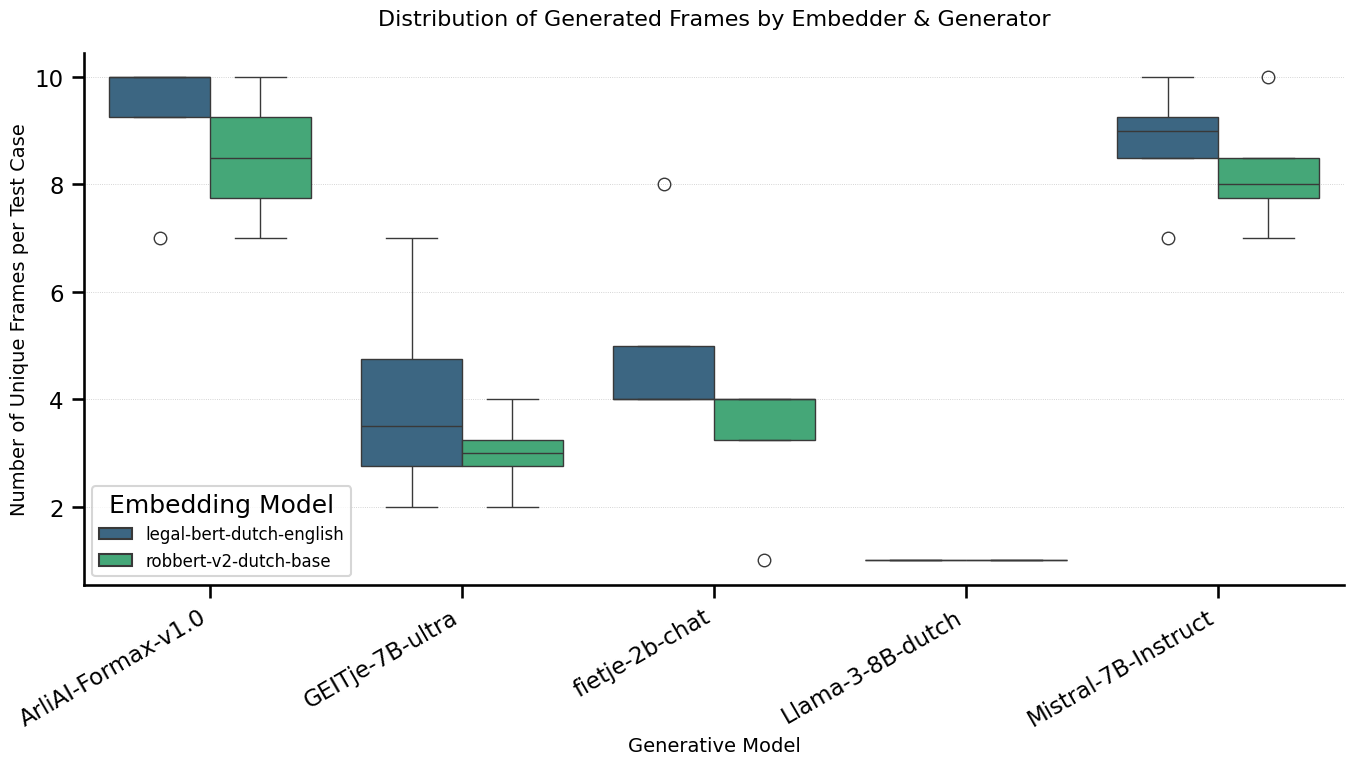

In [ ]:
import json
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def load_and_process_data(json_files):
    """
    Loads data from a list of JSON files and processes it into a pandas DataFrame,
    extracting only the data needed for the frame distribution plot.
    """
    all_results = []
    for file_path in json_files:
        if not os.path.exists(file_path):
            print(f"Warning: File not found, skipping: {file_path}")
            continue

        with open(file_path, 'r', encoding='utf-8') as f:
            try:
                data = json.load(f)
                # Normalize to list if dict
                records = data if isinstance(data, list) else [data]
                for test_case in records:
                    all_results.append({
                        'embedder': test_case.get('embedding_model'),
                        'generator': test_case.get('generative_model'),
                        'num_frames': len(test_case.get('final_unique_frames', []))
                    })
            except json.JSONDecodeError:
                print(f"Warning: Could not decode JSON from {file_path}.")
                continue

    return pd.DataFrame(all_results)

def plot_frame_distribution(df):
    """
    Creates a box plot showing the distribution of unique frames per test case by model,
    using the same style as the bar chart code provided.
    """
    # Shorten embedder names
    df['embedder_short'] = df['embedder'].apply(lambda x: x.split('/')[-1])

    # Shorten generator names
    name_map = {
        'Llama-3.1-8B-ArliAI-Formax-v1.0': 'ArliAI-Formax-v1.0',
        'BramVanroy_GEITje-7B-ultra': 'GEITje-7B-ultra',
        'BramVanroy_fietje-2b-chat': 'fietje-2b-chat',
        'ReBatch_Llama-3-8B-dutch': 'Llama3-8B-dutch',
        'Mistral-7B-Instruct-v0.1': 'Mistral-7B-Instruct'
    }
    df['generator_short'] = df['generator'].apply(
        lambda x: name_map.get(x.split('/')[-1], x.split('/')[-1])
    )

    # --- Plotting ---
    plt.style.use('seaborn-v0_8-paper')
    sns.set_context("talk")
    fig, ax = plt.subplots(figsize=(14, 8))

    sns.boxplot(
        data=df,
        x='generator_short',
        y='num_frames',
        hue='embedder_short',
        palette='viridis',
        ax=ax
    )

    ax.set_ylabel('Number of Unique Frames per Test Case', fontsize=14)
    ax.set_xlabel('Generative Model', fontsize=14)
    ax.set_title('Distribution of Generated Frames by Embedder & Generator', fontsize=16, pad=20)

    # Axis ticks and legend
    plt.xticks(rotation=30, ha='right')
    ax.legend(title='Embedding Model', fontsize=12)
    sns.despine(ax=ax)

    # Add subtle dotted horizontal gridlines
    ax.yaxis.grid(True, linestyle=':', linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

    fig.tight_layout()

    output_filename = 'frame_distribution_boxplot.pdf'
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully as '{output_filename}'")
    plt.show()

# ===================================================================
#                           MAIN EXECUTION
# ===================================================================

json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

results_df = load_and_process_data(json_files)

if not results_df.empty:
    plot_frame_distribution(results_df)
else:
    print("No data loaded; cannot generate the box plot.")


## 8. Frame quality and computation time

In [8]:
import json
import pandas as pd
import os
import re

def analyze_frame_quality(json_files):
    """
    Analyzes the quality and performance of generated FLINT frames from JSON files.

    This function processes a list of JSON files, each containing results
    from a specific model configuration. It calculates metrics for verbosity,
    content concreteness, completeness, extraction score, and execution time.
    It returns two formatted pandas DataFrames summarizing the results.

    Args:
        json_files (list): A list of file paths to the JSON result files.

    Returns:
        tuple: A tuple containing two pandas DataFrames:
               - The first DataFrame contains the quality analysis.
               - The second DataFrame contains the computation time analysis.
    """
    quality_results = []
    time_results = []

    # A dictionary to define keywords for each test case
    test_case_keywords = {
        'TC01': ['vloerisolatie', 'biobased', '30', 'subsidiebedrag'],
        'TC02': ['lucht-waterwarmtepomp', '12 kw', 'a+++', 'berekend'],
        'TC03': ['zonneboiler', 'apertuuroppervlakte', '12', 'vierkante meter'],
        'TC04': ['warmtenet', 'gasmeter', 'elektrische kookvoorziening', 'voorwaarden']
    }

    # Loop through each provided JSON file path
    for file_path in json_files:
        if not os.path.exists(file_path):
            print(f"Warning: File not found at {file_path}. Skipping.")
            continue

        with open(file_path, 'r', encoding='utf-8') as f:
            data = json.load(f)

        # Initialize counters and lists for this file's analysis
        total_frames = 0
        total_words = 0
        frames_with_numbers = 0
        frames_with_currency = 0
        complete_frames = 0
        frames_with_articles = 0
        keyword_match_scores = []
        execution_times = []

        embedding_model = data[0].get('embedding_model', 'N/A')
        generative_model = data[0].get('generative_model', 'N/A')

        # Process each test case within the file
        for test_case_data in data:
            # Collect execution time for each test case
            execution_times.append(test_case_data.get('execution_time_seconds', 0))

            frames = test_case_data.get('final_unique_frames', [])
            if not frames:
                continue

            current_test_case_id = test_case_data.get('test_case_id')
            keywords = test_case_keywords.get(current_test_case_id, [])

            for frame in frames:
                total_frames += 1
                frame_text = ' '.join(str(v) for v in frame.values() if v is not None).lower()

                # 1. Verbosity
                total_words += len(frame_text.split())

                # 2. Keyword Matching
                matches = sum(1 for keyword in keywords if keyword in frame_text)
                keyword_match_scores.append(matches / len(keywords) if keywords else 0)

                # 3. Content Concreteness
                if re.search(r'\d', frame_text):
                    frames_with_numbers += 1
                if '€' in frame_text:
                    frames_with_currency += 1

                # 4. Extraction vs. Abstraction Score
                if 'artikel' in frame_text or 'lid' in frame_text:
                    frames_with_articles += 1

                # 5. Content Completeness
                is_complete = all(frame.get(key) for key in ['actor', 'action', 'object', 'conditions', 'results'])
                if is_complete:
                    complete_frames += 1

        # Calculate final metrics for the quality table
        if total_frames > 0:
            avg_words = total_words / total_frames
            keyword_match_avg = (sum(keyword_match_scores) / len(keyword_match_scores)) * 100 if keyword_match_scores else 0
            pct_with_numbers = (frames_with_numbers / total_frames) * 100
            pct_with_currency = (frames_with_currency / total_frames) * 100
            extraction_score = (frames_with_articles / total_frames) * 100
            field_fill_rate = (complete_frames / total_frames) * 100
        else:
            avg_words, keyword_match_avg, pct_with_numbers, pct_with_currency, extraction_score, field_fill_rate = (0,) * 6

        quality_results.append({
            'Embedding Model': embedding_model.split('/')[-1],
            'Generative Model': generative_model.split('/')[-1],
            'Avg. Words': avg_words,
            'Keyword Match (%)': keyword_match_avg,
            'Frames with Numbers (%)': pct_with_numbers,
            'Frames with Currency (€) (%)': pct_with_currency,
            'Extraction Score (%)': extraction_score,
            'Field Fill Rate (%)': field_fill_rate,
        })

        # Calculate and store results for the time table
        avg_execution_time = sum(execution_times) / len(execution_times) if execution_times else 0
        time_results.append({
            'Embedding Model': embedding_model.split('/')[-1],
            'Generative Model': generative_model.split('/')[-1],
            'Avg. Execution Time (s)': avg_execution_time
        })


    # Create and format the DataFrames
    df_quality = pd.DataFrame(quality_results)
    df_time = pd.DataFrame(time_results)

    pd.set_option('display.max_rows', None)
    pd.set_option('display.max_columns', None)
    pd.set_option('display.width', 1000)
    pd.set_option('display.colheader_justify', 'center')

    quality_cols_to_format = ['Avg. Words', 'Keyword Match (%)', 'Frames with Numbers (%)', 'Frames with Currency (€) (%)', 'Extraction Score (%)', 'Field Fill Rate (%)']
    for col in quality_cols_to_format:
        if col in df_quality.columns:
            df_quality[col] = df_quality[col].map('{:.2f}'.format)

    if 'Avg. Execution Time (s)' in df_time.columns:
        df_time['Avg. Execution Time (s)'] = df_time['Avg. Execution Time (s)'].map('{:.2f}'.format)

    return df_quality, df_time

# --- Main Execution ---
json_files = [
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_Gerwin_legal-bert-dutch-english__gen_mistralai_Mistral-7B-Instruct-v0.1.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ArliAI_Llama-3.1-8B-ArliAI-Formax-v1.0.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_GEITje-7B-ultra.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_BramVanroy_fietje-2b-chat.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_ReBatch_Llama-3-8B-dutch.json',
    '../results/raw/embed_pdelobelle_robbert-v2-dutch-base__gen_mistralai_Mistral-7B-Instruct-v0.1.json'
]

# Generate the analysis tables
quality_table, time_table = analyze_frame_quality(json_files)

# Print the final formatted tables
print("--- Frame Quality Analysis Table ---")
print(quality_table.to_string(index=False))
print("\n" + "="*80 + "\n")
print("--- Computation Time Analysis Table ---")
print(time_table.to_string(index=False))


--- Frame Quality Analysis Table ---
    Embedding Model              Generative Model        Avg. Words Keyword Match (%) Frames with Numbers (%) Frames with Currency (€) (%) Extraction Score (%) Field Fill Rate (%)
legal-bert-dutch-english Llama-3.1-8B-ArliAI-Formax-v1.0   37.68          33.11                59.46                     10.81                    18.92                100.00      
legal-bert-dutch-english                 GEITje-7B-ultra   52.25          65.62                81.25                      6.25                    37.50                100.00      
legal-bert-dutch-english                  fietje-2b-chat   33.45          67.50                65.00                      5.00                    10.00                 75.00      
legal-bert-dutch-english                Llama-3-8B-dutch   50.00           6.25                 0.00                      0.00                     0.00                100.00      
legal-bert-dutch-english        Mistral-7B-Instruct-v0.1   44.7